# Exploring Clusters

This notebook explores the clusters that were formed by the K-Means Clustering in the notebook `module_1_clustering.ipynb`. Specifically, the goal is to determine the structure of the clusters across the real-estate, social and commercial dimension. 

## Load packages and Data

In [42]:
#load packages
import pandas as pd 
import numpy as np
from sklearn.impute import KNNImputer
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
import seaborn as sns
from matplotlib.patches import Patch

In [43]:
#load dataframes 
clusters = pd.read_csv("../../data/Module_1/cluster_assignments.csv", dtype={"plr_id": str})
features = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
ms = pd.read_csv("../../data/Module 2/target_milieuschutz.csv", dtype={"plr_id": str})
watchlist = pd.read_csv("../../models/df_backup.csv", dtype={"plr_id": str})

#define id columns and feature columns
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in features.columns if c not in id_cols]

features.head(2)
print(features.shape)

(527, 45)


In [3]:
#merge clusters 
df_merge1 = features.merge(clusters, on="plr_id", how="left")
#check 
print(df_merge1.shape)

(527, 47)


In [4]:
#merge milieuschutz areas 
df = df_merge1.merge(ms, on = ['plr_id', 'plr_name', 'bez'], how = "left")
print(df.shape)
df.head(2)

(527, 49)


,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,milieu_anteil,milieu_majoritaet
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.003153,-0.00280,0.001395,13.000000,0.118160,0.102663,2,1,0.0,0
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.004856,-0.00093,-0.000664,129.333333,0.228719,0.297506,2,1,0.0,0


In [5]:
#rename columns from german > english (ms = milieuschutz: protected area under § 172 BGB)
df.rename(columns={"milieu_anteil": "ms_portion", "milieu_majoritaet": "ms_over50"}, inplace = True)
df.head()

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_over50
0,01100101,Stülerstraße,01 - Mitte,22.70,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.003153,-0.002800,0.001395,13.000000,0.118160,0.102663,2,1,0.000000e+00,0
1,01100102,Großer Tiergarten,01 - Mitte,20.30,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.004856,-0.000930,-0.000664,129.333333,0.228719,0.297506,2,1,0.000000e+00,0
2,01100103,Lützowstraße,01 - Mitte,23.00,1.356,1.863997,3541.826020,-0.440097,16.223680,0.455,...,0.000177,-0.001019,0.000103,43.833333,0.323783,0.130135,2,1,7.967912e-01,1
3,01100104,Körnerstraße,01 - Mitte,26.21,2.276,1.721377,3499.906289,-0.451978,24.819856,0.507,...,0.001706,0.000616,-0.008733,31.833333,0.277822,0.189752,2,1,8.400603e-01,1
4,01100205,Wilhelmstraße,01 - Mitte,26.08,1.583,4.478708,9000.000000,-0.287682,24.963289,0.493,...,0.002437,-0.001641,0.001402,109.833333,0.168869,0.254038,2,1,2.602949e-08,0


In [6]:
#add columns for ms_over60, ms_over70, ms_over80, ms_over90
df["ms_over60"] = (df["ms_portion"] > 0.6).astype(int)
df["ms_over70"] = (df["ms_portion"] > 0.7).astype(int)
df["ms_over80"] = (df["ms_portion"] > 0.8).astype(int)
df["ms_over90"] = (df["ms_portion"] > 0.9).astype(int)
df.sample(5)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_over50,ms_over60,ms_over70,ms_over80,ms_over90
95,03300411,Karow Nord,03 - Pankow,10.98,0.567,0.838613,454.873060,-0.064595,0.372717,0.342,...,0.002236,0.070816,1,2,0.0,0,0,0,0,0
510,12400720,Frohnau West,12 - Reinickendorf,14.47,0.727,2.300272,749.995652,0.000003,1.484047,0.217,...,0.030423,0.041059,0,0,0.0,0,0,0,0,0
148,04200309,Neu Westend,04 - Charlottenburg-Wilmersdorf,18.00,1.219,1.725013,1438.610891,-0.395130,3.044140,0.339,...,0.022577,0.016743,0,1,0.0,0,0,0,0,0
191,04501153,Babelsberger Straße,04 - Charlottenburg-Wilmersdorf,23.67,2.243,2.737482,3814.215063,-0.452985,3.977539,0.427,...,0.434020,0.060833,2,1,0.0,0,0,0,0,0
167,04400729,Hundekehle,04 - Charlottenburg-Wilmersdorf,20.02,0.282,3.411371,2647.028483,-0.036951,2.006689,0.254,...,0.186622,0.110368,0,0,0.0,0,0,0,0,0


In [7]:
#sanity check
cols = ["ms_over60", "ms_over70", "ms_over80", "ms_over90"]
different = df[df[cols].nunique(axis=1) > 1]
different.sample(10)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,re_altbau_share,re_neubau_share,cluster_3k,cluster_4k,ms_portion,ms_over50,ms_over60,ms_over70,ms_over80,ms_over90
102,03400721,Florakiez,03 - Pankow,18.00,1.215,1.445783,1259.997680,-0.685165,7.228916,0.383,...,0.601377,0.139071,2,3,0.867962,1,1,1,1,0
45,01401046,Nordufer,01 - Mitte,16.32,1.588,2.453517,1400.000000,-0.405465,8.242285,0.559,...,0.686026,0.027219,2,3,0.742398,1,1,1,0,0
282,07100205,Alvenslebenstraße,07 - Tempelhof-Schöneberg,8.84,0.909,4.552590,3027.414478,-0.396422,10.596546,0.419,...,0.317896,0.010989,2,3,0.762444,1,1,1,0,0
82,02500834,Revaler Straße,02 - Friedrichshain-Kreuzberg,20.97,1.199,1.253676,4500.000000,-0.200671,21.513698,0.556,...,0.792602,0.081102,2,3,0.723756,1,1,1,0,0
331,08100206,Flughafenstraße,08 - Neukölln,15.68,1.375,1.932741,2202.450703,-0.491363,28.991109,0.534,...,0.853305,0.022227,2,3,0.796960,1,1,1,0,0
480,11400929,Weitlingkiez,11 - Lichtenberg,14.58,1.729,1.867322,1465.998628,-0.275663,5.503686,0.537,...,0.280491,0.073808,2,3,0.873725,1,1,1,1,0
335,08100310,Maybachufer,08 - Neukölln,19.71,0.886,1.403590,2800.198220,-0.356636,21.859181,0.483,...,0.729176,0.001150,2,3,0.889019,1,1,1,1,0
340,08100415,Ganghoferstraße,08 - Neukölln,18.51,1.402,2.474657,2200.000000,-0.492476,13.714967,0.534,...,0.710793,0.012522,2,3,0.856740,1,1,1,1,0
66,02300418,Reichenberger Straße Ost,02 - Friedrichshain-Kreuzberg,21.31,1.268,2.096627,2999.479376,-0.405454,31.449407,0.464,...,0.671149,0.016408,2,3,0.877399,1,1,1,1,0
339,08100314,Donaustraße,08 - Neukölln,14.86,1.437,1.530853,2200.032452,-0.492468,23.080546,0.551,...,0.827838,0.006359,2,3,0.864507,1,1,1,1,0


In [8]:
#merge the watchlist columns 
watchlist.head(2)

,plr_id,oof_prob,on_watchlist
0,01100101,0.005072,False
1,01100102,0.445204,False


In [9]:
df_merge2 = df.merge(watchlist, on = ['plr_id'], how = "left")
df_merge2.head(2)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,cluster_3k,cluster_4k,ms_portion,ms_over50,ms_over60,ms_over70,ms_over80,ms_over90,oof_prob,on_watchlist
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,2,1,0.0,0,0,0,0,0,0.005072,False
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,2,1,0.0,0,0,0,0,0,0.445204,False


In [10]:
#save 
#df_merge2.to_csv("../../data/final_datasets/df_clusters_milieuschutz.csv", index=False)
df_merge2.head(2)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,cluster_3k,cluster_4k,ms_portion,ms_over50,ms_over60,ms_over70,ms_over80,ms_over90,oof_prob,on_watchlist
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,2,1,0.0,0,0,0,0,0,0.005072,False
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,2,1,0.0,0,0,0,0,0,0.445204,False


## Gentrification Profiles

### Map

To get an overview of the geographic spread of the clusters across Berlin, let's look at them on a map.

In [11]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr_geo = gpd.read_file(url)

# get plr-id's to strings with len 8
plr_geo["plr_id"] = plr_geo["plr_id"].astype(str).str.zfill(8)
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)

gdf = plr_geo.merge(df[["plr_id_str", "cluster_4k"]],
                    left_on="plr_id", right_on="plr_id_str", how="left")
print("matched:", gdf["cluster_4k"].notna().sum(), "von", len(gdf))

matched: 527 von 542


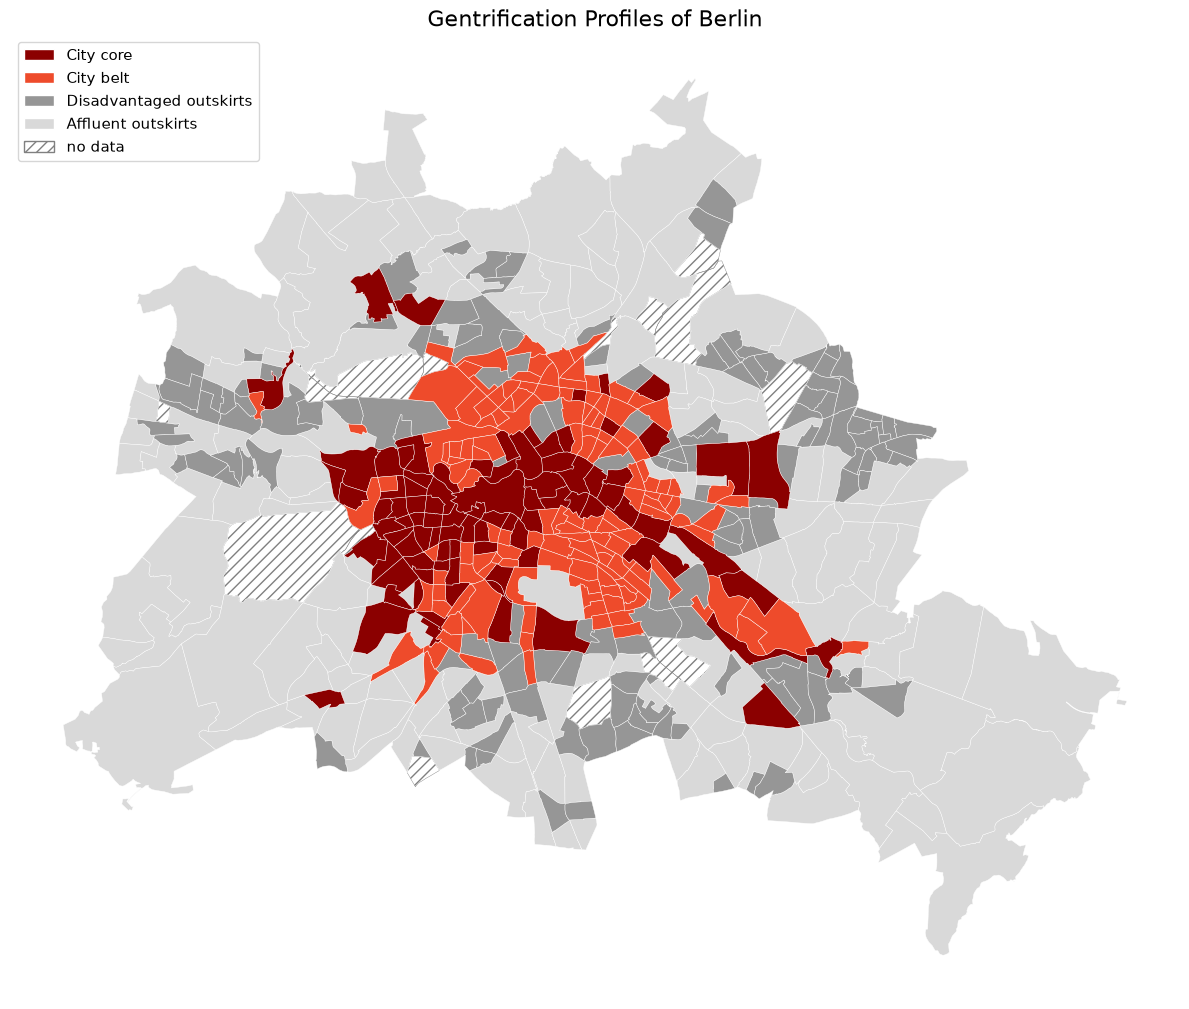

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 12))
k = 4

cluster_colors = {
    3: "#EE4B2B",   # City belt — bright red 
    1: "#8B0000",   # City core — dark red 
    2: "#969696",   # Disadvantaged outskirts — mittelgrau
    0: "#d9d9d9",   # Affluent outskirts — helleres grau
}
cluster_labels = {
    1: "City core",
    3: "City belt",
    2: "Disadvantaged outskirts",
    0: "Affluent outskirts",
}

gdf[gdf["cluster_4k"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3)


# Kontext-Cluster zuerst, dann City ring zuletzt (liegt oben)
for c in [0, 2, 1, 3]:
    gdf[gdf["cluster_4k"] == c].plot(
        ax=ax, color=cluster_colors[c], edgecolor="white", linewidth=0.3)

handles = [Patch(facecolor=cluster_colors[c], edgecolor="white", label=cluster_labels[c])
           for c in [1, 3, 2, 0]]   # City ring zuerst in der Legende
handles.append(Patch(facecolor="none", edgecolor="grey", hatch="///", label="no data"))
ax.legend(handles=handles, loc="upper left", fontsize=11, frameon=True)

ax.set_title(f"Gentrification Profiles of Berlin", fontsize=16)
ax.axis("off"); plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/cluster_map.png", dpi=300, bbox_inches="tight")
plt.show()

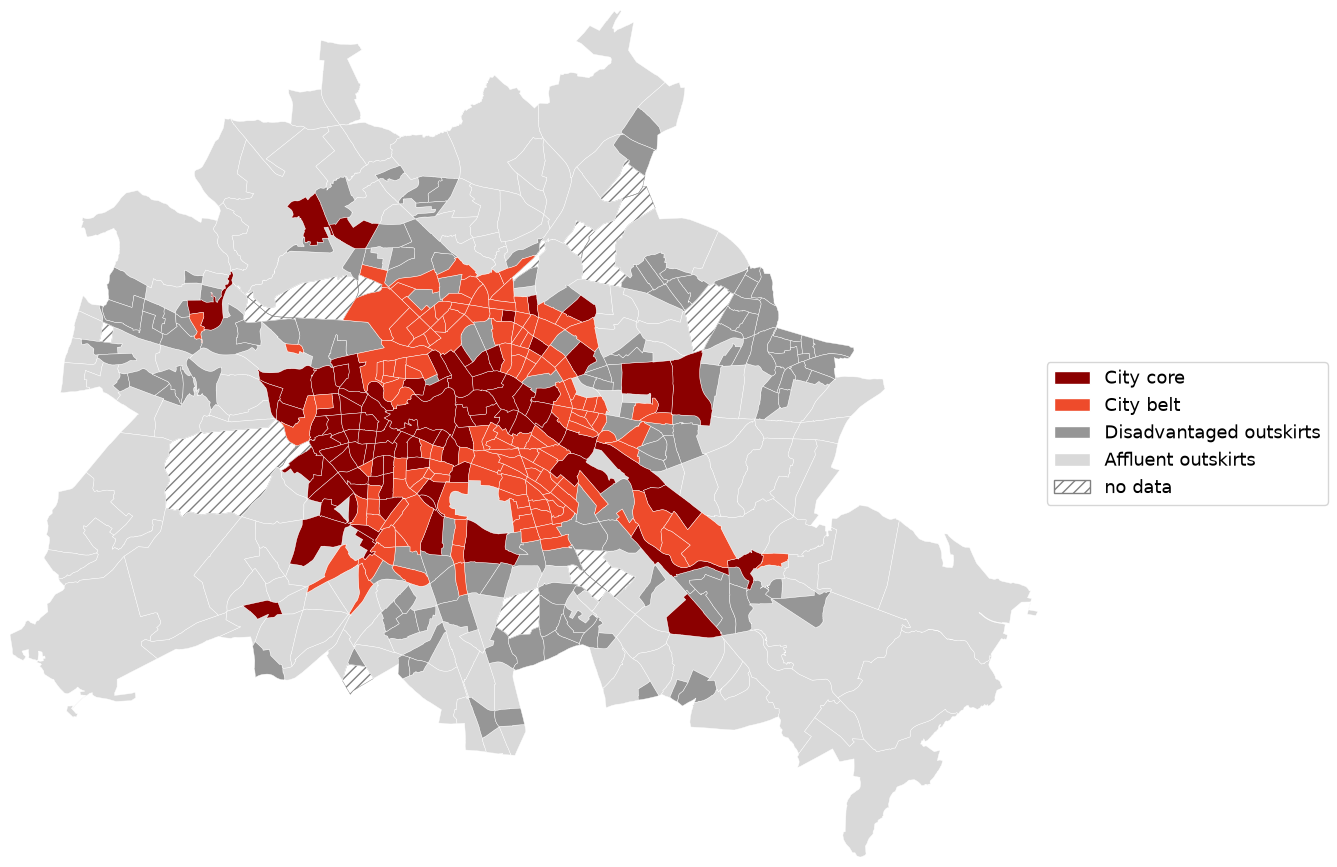

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(16, 11))
k = 4

cluster_colors = {
    3: "#EE4B2B",   # City belt — bright red
    1: "#8B0000",   # City core — dark red
    2: "#969696",   # Disadvantaged outskirts
    0: "#d9d9d9",   # Affluent outskirts
}
cluster_labels = {
    1: "City core",
    3: "City belt",
    2: "Disadvantaged outskirts",
    0: "Affluent outskirts",
}

gdf[gdf["cluster_4k"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3)

for c in [0, 2, 1, 3]:
    gdf[gdf["cluster_4k"] == c].plot(
        ax=ax, color=cluster_colors[c], edgecolor="white", linewidth=0.3)

handles = [Patch(facecolor=cluster_colors[c], edgecolor="white", label=cluster_labels[c])
           for c in [1, 3, 2, 0]]
handles.append(Patch(facecolor="none", edgecolor="grey", hatch="///", label="no data"))
ax.legend(handles=handles,
          loc="center left",
          bbox_to_anchor=(1.0, 0.5),   # rechts neben der Karte
          fontsize=13, frameon=True)

ax.axis("off")
ax.margins(0)
fig.savefig("../../plots/presentation/cluster_map.png",
            dpi=300, bbox_inches="tight", pad_inches=0.1)
plt.show()

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

cluster_labels = {1:"City core", 3:"City belt",
                  2:"Disadvantaged outskirts", 0:"Affluent outskirts"}
muted = "#f0f0f0"   # heller Hintergrund, damit auch graue Fokus-Cluster abstechen
highlight_color = {1:"#8B0000", 3:"#EE4B2B", 2:"#737373", 0:"#969696"}
# Disadvantaged dunkler (#737373), Affluent mittel (#969696) — beide klar über dem blassen Hintergrund

for focus in [1, 3, 2, 0]:
    fig, ax = plt.subplots(figsize=(16, 11))

    # no-data
    gdf[gdf["cluster_4k"].isna()].plot(ax=ax, color="none", edgecolor="grey",
                                        hatch="///", linewidth=0.3)
    # alle anderen Cluster blass
    for c in [0, 2, 1, 3]:
        if c != focus:
            gdf[gdf["cluster_4k"] == c].plot(ax=ax, color=muted,
                                              edgecolor="white", linewidth=0.3)
    # der fokussierte Cluster zuletzt, in Farbe, oben
    gdf[gdf["cluster_4k"] == focus].plot(ax=ax, color=highlight_color[focus],
                                          edgecolor="white", linewidth=0.3)

    ax.axis("off"); ax.margins(0)
    fname = f"../../plots/presentation/map_{cluster_labels[focus].replace(' ','_')}.png"
    fig.savefig(fname, dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.close(fig)
    print("saved:", fname)

saved: ../../plots/presentation/map_City_core.png
saved: ../../plots/presentation/map_City_belt.png
saved: ../../plots/presentation/map_Disadvantaged_outskirts.png
saved: ../../plots/presentation/map_Affluent_outskirts.png


In order to determine whether the clusters can actually be described as gentrification phases/profiles, we need to take a look at what separates them and what characterizes each cluster. 

### Trend vs. Level:

In [15]:
def is_dynamic(c):
    return any(t in c for t in ["_trend", "_slope", "_change"])

for label, cols in [("LEVEL", [c for c in feat_cols if not is_dynamic(c)]),
                    ("DYNAMIC", [c for c in feat_cols if is_dynamic(c)])]:
    print(f"\n{'='*60}\n{label}\n{'='*60}")
    print(df.groupby("cluster_4k")[cols].median().T.round(2).to_string())


LEVEL
cluster_4k                                    0        1       2        3
re_miete_niveau                           14.00    20.00   10.28    16.84
re_leerstandsquote                         1.93     2.17    1.55     1.76
re_brw_niveau                            651.18  3274.09  579.53  2200.00
re_dichte_all                              2.31     9.37    0.70    10.42
soc_young_to_middle_adult_share_2025       0.30     0.42    0.37     0.46
soc_average_household_size_2024            1.96     1.67    1.80     1.65
soc_internal_migration_volume_rate_2025    0.12     0.18    0.14     0.17
soc_internal_net_migration_rate_2025       0.01    -0.00    0.01    -0.01
soc_transfer_benefit_share_2024            0.05     0.07    0.13     0.10
soc_single_parent_household_share_2024     0.04     0.04    0.06     0.04
com_median_age_level_2026                  8.00     7.00    5.00     6.00
com_share_solo_level_2026                  0.70     0.59    0.81     0.75
com_share_10plus_level_2026    

Cluster overview (k=4): Clusters are **level-driven** — dynamic variables are near-zero everywhere except rent trend. They describe gentrification states, not phases.
- 1: highest rents & land values, densest Airbnb, strongest upscale gastro 
- 3:  most pre-war buildings, youngest residents, high churn (exit rate, rent trend)
- 2: lowest values, highest benefit dependency, sparse unstable commerce 
- 0: low density but wealthy — largest households, oldest businesses, stable values

### Dimensions within profiles

First, let's look at a few variables that seem interesting based on prior knowledge of the data. 

42 Features


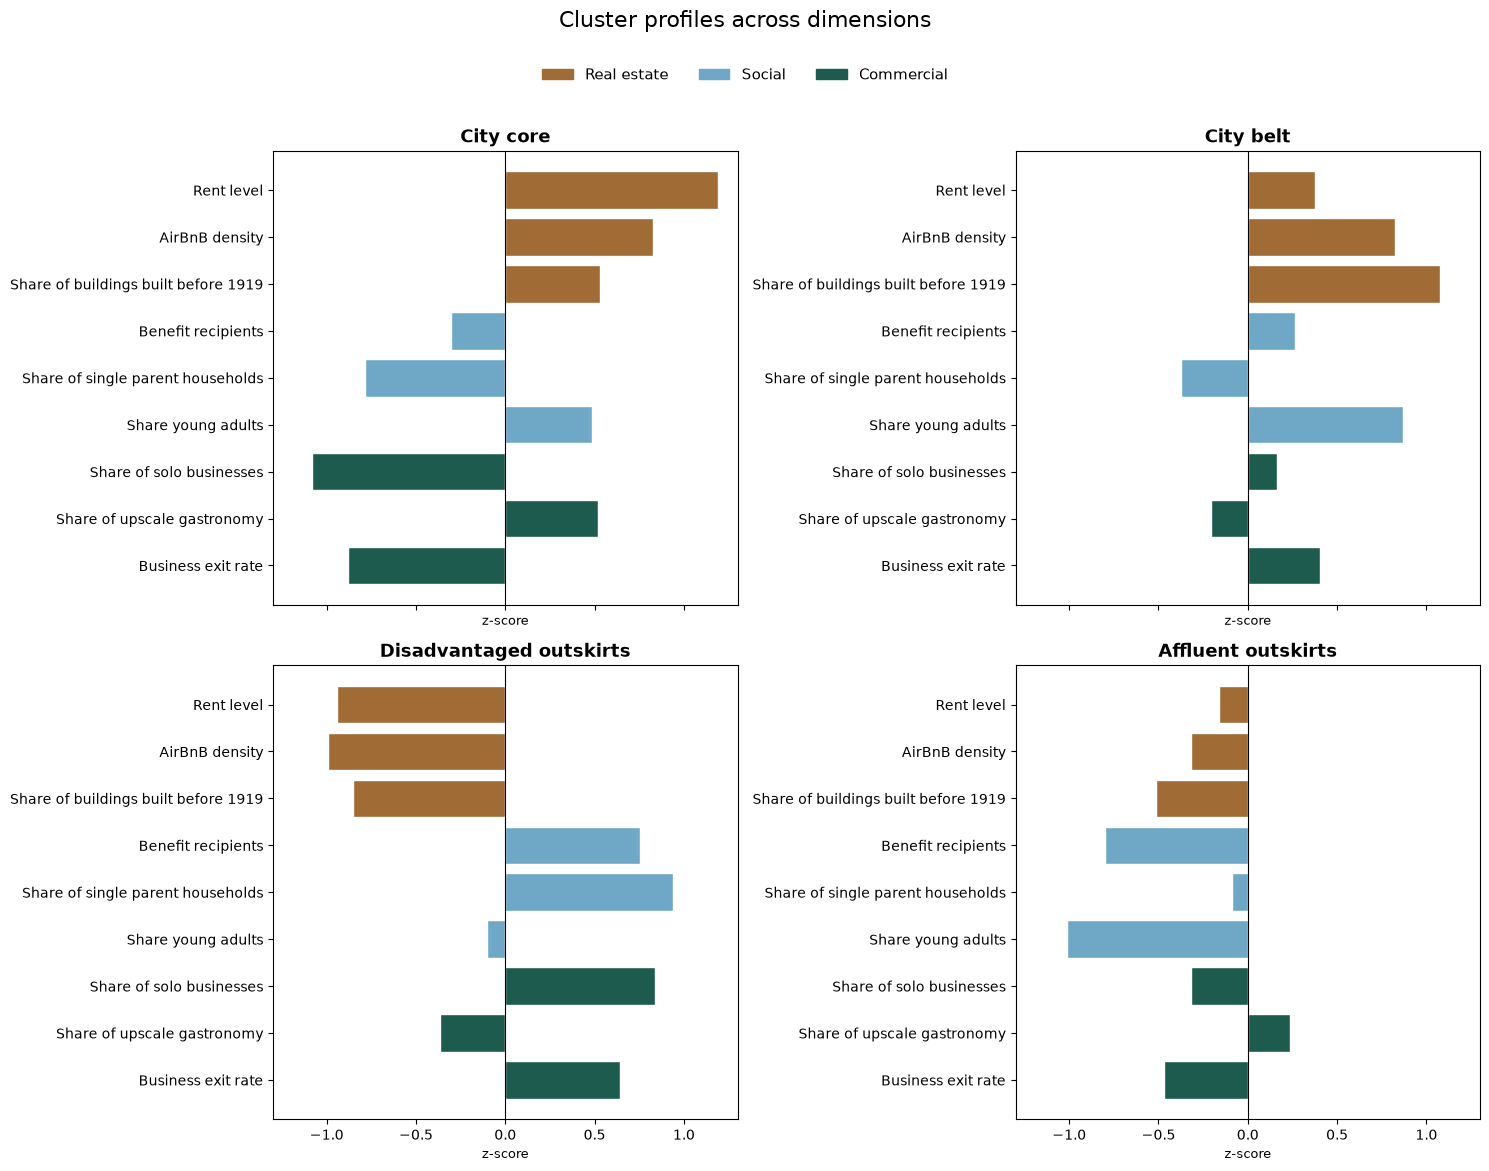

In [16]:
# prepare data
id_cols = ["plr_id", "plr_name", "bez"]
non_features = id_cols + ["cluster_3k", "cluster_4k", "ms_portion", "ms_over50",
                          "plr_id_str", "ms_over60", "ms_over70", "ms_over80", "ms_over90"]
feat_cols = [c for c in df.columns if c not in non_features]
print(len(feat_cols), "Features")

X = df[feat_cols]
X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X),
    columns=feat_cols, index=X.index,
)

Xs = X_scaled.copy()
Xs["cluster_4k"] = df["cluster_4k"].values

chosen = ["re_miete_niveau", "re_dichte_all", "re_altbau_share",                # land value, airbnb density, pre-war buildings
          "soc_transfer_benefit_share_2024", "soc_single_parent_household_share_2024", "soc_young_to_middle_adult_share_2025",  # benefit recipients, single-parent share, young adults
          "com_share_solo_level_2026", "com_upscale_share_level_2026", "com_exit_rate_level_2026"]  # solo businesses, upscale gastronomy, exit rate

axis_labels = {
    "re_miete_niveau": "Rent level",
    "re_dichte_all": "AirBnB density",
    "re_altbau_share": "Share of buildings built before 1919",
    "soc_transfer_benefit_share_2024": "Benefit recipients",
    "soc_single_parent_household_share_2024": "Share of single parent households",
    "soc_young_to_middle_adult_share_2025": "Share young adults",
    "com_share_solo_level_2026": "Share of solo businesses",
    "com_upscale_share_level_2026": "Share of upscale gastronomy",
    "com_exit_rate_level_2026": "Business exit rate",
}

# re_ = Ocker, soc_ = Blau, com_ = Grün
dim_color = {"re_": "#A06B34", "soc_": "#6FA8C7", "com_": "#1D5B4E"}
bar_colors = [next(dim_color[p] for p in dim_color if v.startswith(p)) for v in chosen]

z = Xs.groupby("cluster_4k")[chosen].mean()

labels = {1: "City core", 3: "City belt",
          2: "Disadvantaged outskirts", 0: "Affluent outskirts"}
order = [1, 3, 2, 0]

fig, axes = plt.subplots(2, 2, figsize=(15, 11), sharex=True)
ypos = np.arange(len(chosen))
for ax, c in zip(axes.flat, order):
    ax.barh(ypos, z.loc[c, chosen].values, color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(ypos); ax.set_yticklabels([axis_labels[v] for v in chosen], fontsize=10)
    ax.invert_yaxis()
    ax.set_title(labels[c], fontsize=13, fontweight="bold")
    ax.set_xlabel("z-score", fontsize=9); ax.set_xlim(-1.3, 1.3)

handles = [Patch(color="#A06B34", label="Real estate"),
           Patch(color="#6FA8C7", label="Social"),
           Patch(color="#1D5B4E", label="Commercial")]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 1.02), frameon=False)
fig.suptitle("Cluster profiles across dimensions", fontsize=16, y=1.06)
plt.tight_layout()
fig.savefig("../../plots/gentrification_profiles/cluster_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

The plots reveal how the four clusters separate along different dimensions.The City core combines the highest rents and Airbnb density with a mature commercial fabric - the fewest solo businesses and lowest exit rate — and low benefit dependency. The City belt shares this real-estate strength, led by the highest pre-war building share and young-adult concentration, but shows the opposite commercial signal: a positive business exit rate marking active churn rather than the core's stability. The Disadvantaged outskirts invert the real-estate profile (low across all three) and stand out socially — the highest single-parent share and benefit dependency — alongside many solo businesses and high turnover. The Affluent outskirts are low-density but socially secure: the lowest young-adult share and benefit dependency, with a small positive upscale-gastronomy signal.

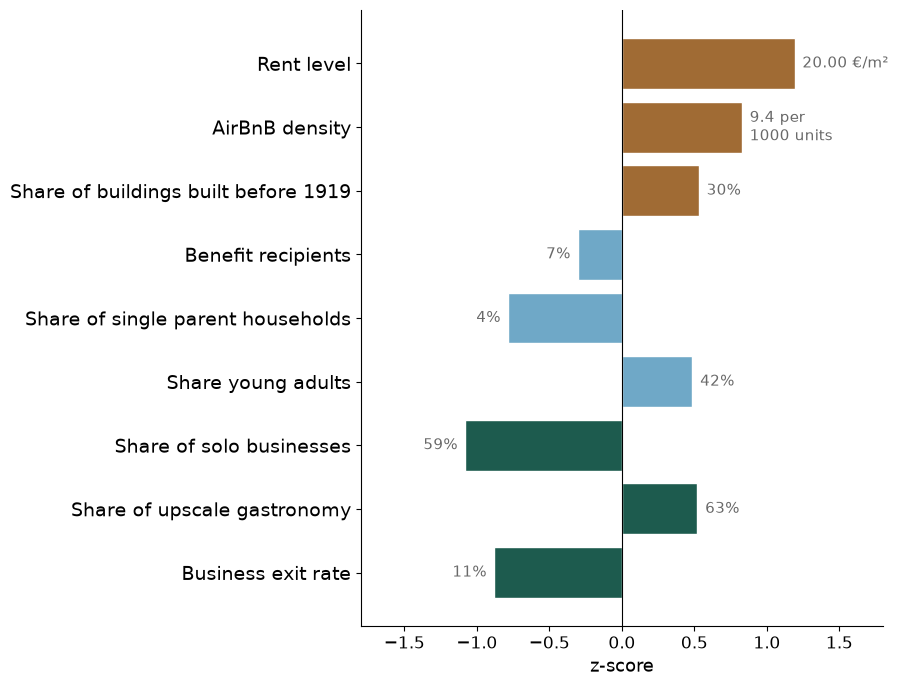

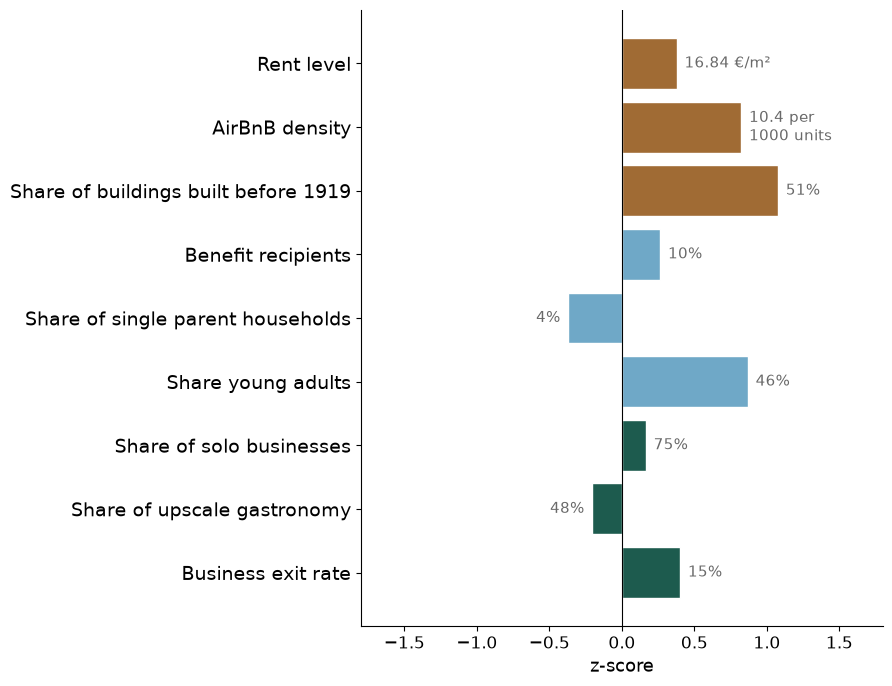

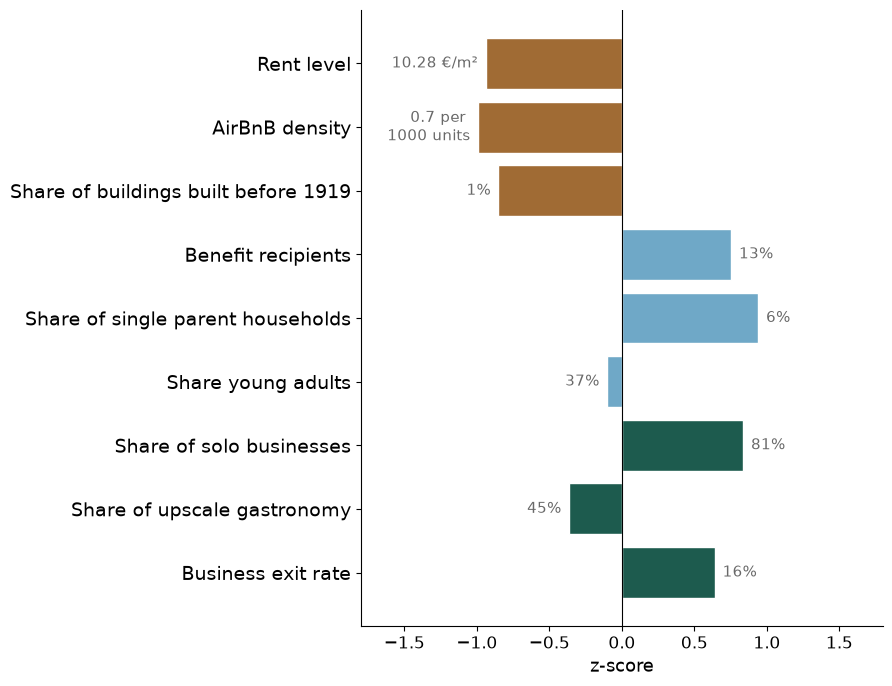

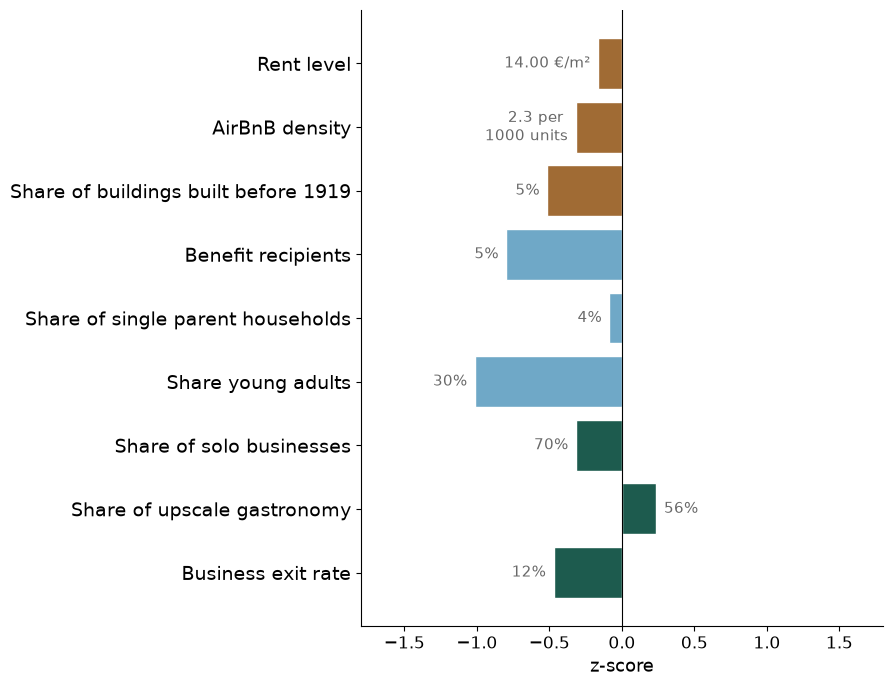

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

plt.close("all")

# ── prepare data ─────────────────────────────────────────────
id_cols = ["plr_id", "plr_name", "bez"]
non_features = id_cols + ["cluster_3k", "cluster_4k", "ms_portion", "ms_over50",
                          "plr_id_str", "ms_over60", "ms_over70", "ms_over80", "ms_over90"]
feat_cols = [c for c in df.columns if c not in non_features]

X = df[feat_cols]
X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X),
    columns=feat_cols, index=X.index,
)

Xs = X_scaled.copy()
Xs["cluster_4k"] = df["cluster_4k"].values

chosen = ["re_miete_niveau", "re_dichte_all", "re_altbau_share",
          "soc_transfer_benefit_share_2024", "soc_single_parent_household_share_2024",
          "soc_young_to_middle_adult_share_2025",
          "com_share_solo_level_2026", "com_upscale_share_level_2026", "com_exit_rate_level_2026"]

# ── force-clean definitions (prevents stale-variable collisions) ──
axis_labels = {
    "re_miete_niveau": "Rent level",
    "re_dichte_all": "AirBnB density",
    "re_altbau_share": "Share of buildings built before 1919",
    "soc_transfer_benefit_share_2024": "Benefit recipients",
    "soc_single_parent_household_share_2024": "Share of single parent households",
    "soc_young_to_middle_adult_share_2025": "Share young adults",
    "com_share_solo_level_2026": "Share of solo businesses",
    "com_upscale_share_level_2026": "Share of upscale gastronomy",
    "com_exit_rate_level_2026": "Business exit rate",
}
assert axis_labels["re_dichte_all"] == "AirBnB density", "stale variable — restart kernel"

fmt_map = {
    "re_miete_niveau": lambda v: f"{v:.2f} €/m²",
    "re_dichte_all": lambda v: f"{v:.1f} per \n1000 units",
    "re_altbau_share": lambda v: f"{v:.0%}",
    "soc_transfer_benefit_share_2024": lambda v: f"{v:.0%}",
    "soc_single_parent_household_share_2024": lambda v: f"{v:.0%}",
    "soc_young_to_middle_adult_share_2025": lambda v: f"{v:.0%}",
    "com_share_solo_level_2026": lambda v: f"{v:.0%}",
    "com_upscale_share_level_2026": lambda v: f"{v:.0%}",
    "com_exit_rate_level_2026": lambda v: f"{v:.0%}",
}

dim_color = {"re_": "#A06B34", "soc_": "#6FA8C7", "com_": "#1D5B4E"}
bar_colors = [next(dim_color[p] for p in dim_color if v.startswith(p)) for v in chosen]

z = Xs.groupby("cluster_4k")[chosen].mean()
raw_median = df.groupby("cluster_4k")[chosen].median()

labels = {1: "City core", 3: "City belt",
          2: "Disadvantaged outskirts", 0: "Affluent outskirts"}
order = [1, 3, 2, 0]

xmax = np.ceil(z[chosen].abs().max().max() * 10) / 10 + 0.6
ypos = np.arange(len(chosen))

# ── one separate saved plot per cluster, no title, no legend ──
for c in order:
    fig, ax = plt.subplots(figsize=(9, 8))
    fig.subplots_adjust(left=0.32)

    vals = z.loc[c, chosen].values
    ax.barh(ypos, vals, color=bar_colors, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(ypos)
    ax.set_yticklabels([axis_labels[v] for v in chosen], fontsize=14)
    ax.tick_params(axis="x", labelsize=12)
    ax.invert_yaxis()
    ax.set_xlabel("z-score", fontsize=13)
    ax.set_xlim(-xmax, xmax)

    for i, (val, feat) in enumerate(zip(vals, chosen)):
        raw_val = raw_median.loc[c, feat]
        label_txt = fmt_map[feat](raw_val)
        pad = xmax * 0.03
        x = val + pad if val >= 0 else val - pad
        ha = "left" if val >= 0 else "right"
        ax.text(x, i, label_txt, va="center", ha=ha, fontsize=11, color="dimgray")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    slug = labels[c].lower().replace(" ", "_")
    fig.savefig(f"../../plots/presentation/cluster_{slug}.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

### Most discriminating variables:

So far, the variable selection has been interest-driven. Let's look at a data-driven selection of variables that seperate the clusters.

In [18]:
# show the 20 most discriminating variables 
means_by_cluster = Xs.groupby("cluster_4k")[feat_cols].apply(
    lambda g: g.mean())   

Xs = X_scaled.copy(); Xs["cluster_4k"] = df["cluster_4k"].values
spread = Xs.groupby("cluster_4k")[feat_cols].mean().var().sort_values(ascending=False)
print(spread.head(20))

re_brw_niveau                                  0.865307
re_miete_niveau                                0.805934
re_altbau_share                                0.805855
re_dichte_all                                  0.805692
soc_young_to_middle_adult_share_2025           0.671929
com_share_solo_level_2026                      0.652160
re_brw_trend                                   0.606369
com_n_gastro                                   0.550424
soc_single_parent_household_share_2024         0.541097
com_exit_rate_level_2026                       0.515219
com_median_age_level_2026                      0.504414
soc_average_household_size_2024                0.479698
soc_transfer_benefit_share_2024                0.454840
com_entry_rate_level_2026                      0.375490
com_tourism_share_level_2026                   0.338258
soc_internal_migration_volume_rate_2025        0.329522
soc_transfer_benefit_share_change_2020_2024    0.326458
re_miete_trend                                 0

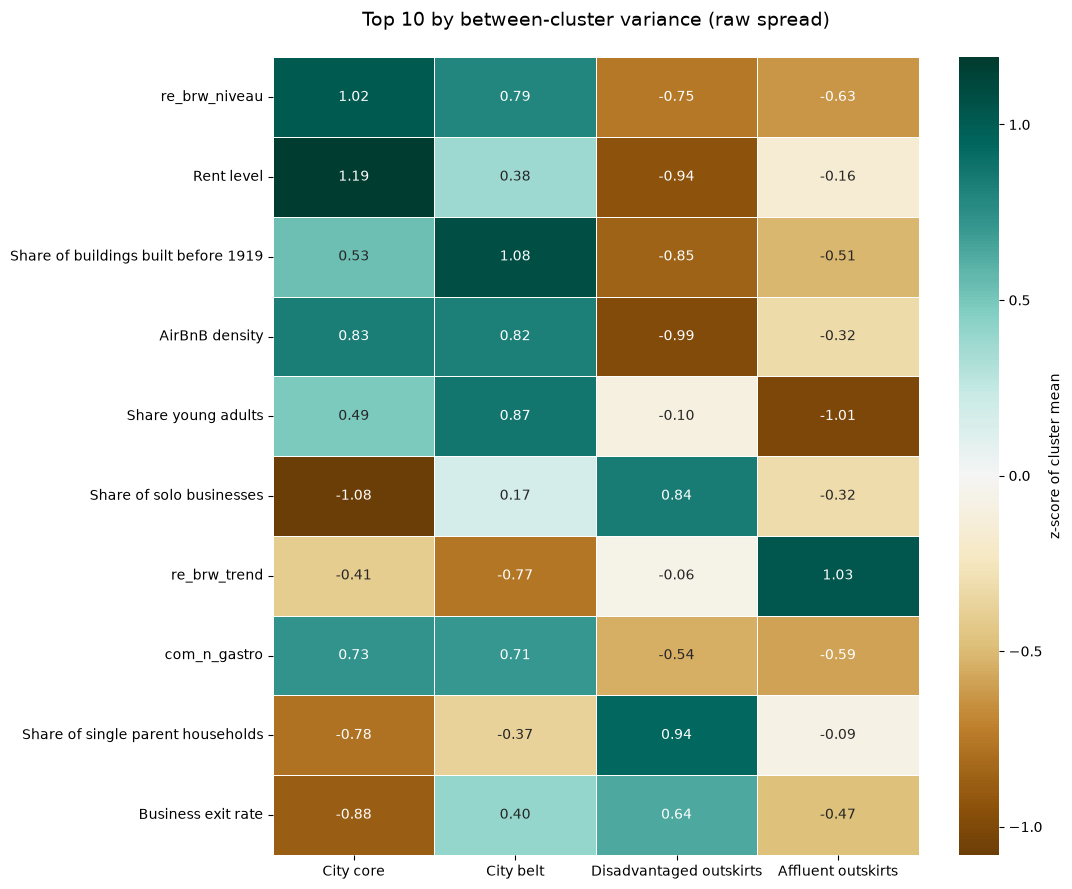

In [19]:
# rohe Top-10 nach spread — zum Ansehen und Verwerfen
spread = Xs.groupby("cluster_4k")[feat_cols].mean().var().sort_values(ascending=False)
chosen = spread.head(10).index.tolist()

labels = {1:"City core", 3:"City belt", 2:"Disadvantaged outskirts", 0:"Affluent outskirts"}
order = [1, 3, 2, 0]

zt = Xs.groupby("cluster_4k")[chosen].mean().reindex(order).T
zt.columns = [labels[c] for c in order]
zt.index = [axis_labels.get(v, v) for v in chosen]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(zt, cmap="BrBG", center=0, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "z-score of cluster mean"}, ax=ax)
ax.set_title("Top 10 by between-cluster variance (raw spread)\n", fontsize=14)
plt.tight_layout()
plt.show()

A purely variance-based top-10 selection over-represents the correlated real-estate variables and includes land value trend (high variance but negligible absolute differences), so a balanced three-per-dimension selection is explored as an alternative.

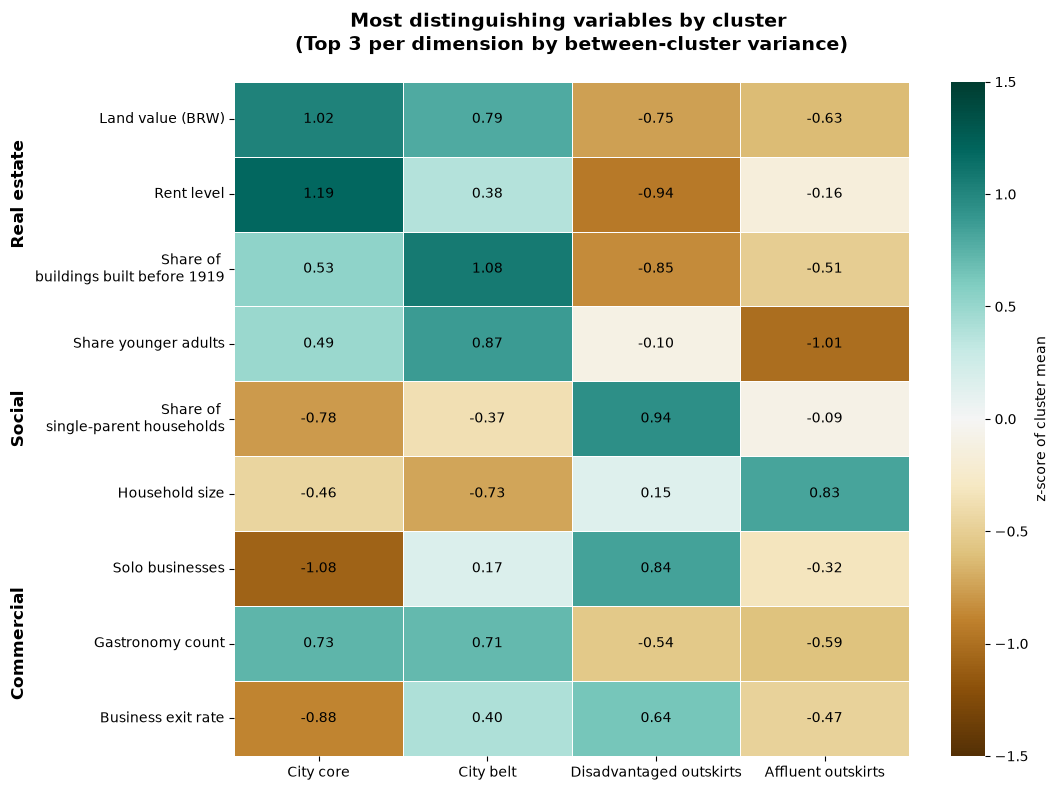

In [20]:
spread = Xs.groupby("cluster_4k")[feat_cols].mean().var()
chosen = []
for pre in ["re_", "soc_", "com_"]:
    dim = spread[[c for c in feat_cols if c.startswith(pre)]].sort_values(ascending=False)
    chosen += dim.head(3).index.tolist()

axis_labels = {
    "re_brw_niveau":"Land value (BRW)", "re_dichte_all":"AirBnB density",
    "re_miete_niveau":"Rent level", "re_altbau_share":"Share of \nbuildings built before 1919",
    "soc_single_person_hh_share_2024":"Single-person households",
    "soc_young_to_middle_adult_share_2025":"Share younger adults",
    "soc_single_parent_household_share_2024":"Share of \nsingle-parent households",
    "soc_average_household_size_2024":"Household size",
    "com_share_solo_level_2026":"Solo businesses",
    "com_exit_rate_level_2026":"Business exit rate", "com_n_gastro":"Gastronomy count",
}
labels = {1:"City core", 3:"City belt", 2:"Disadvantaged outskirts", 0:"Affluent outskirts"}
order = [1, 3, 2, 0]

zt = Xs.groupby("cluster_4k")[chosen].mean().reindex(order).T
zt.columns = [labels[c] for c in order]
zt.index = [axis_labels.get(v, v) for v in chosen]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(zt, cmap="BrBG", center=0, annot=True, fmt=".2f",
            vmin=-1.5, vmax=1.5, linewidths=0.5, linecolor="white",
            annot_kws={"color":"black","fontsize":10},
            cbar_kws={"label":"z-score of cluster mean"}, ax=ax)


# Dimensionsnamen links neben den Blöcken (Blockmitte: 1.5, 4.5, 7.5)
dim_names = [("Real estate", 1.5), ("Social", 4.5), ("Commercial", 7.5)]
for name, ypos in dim_names:
    ax.text(-0.32, ypos, name, transform=ax.get_yaxis_transform(),
            rotation=90, va="center", ha="center",
            fontsize=12, fontweight="bold")

plt.title("Most distinguishing variables by cluster \n(Top 3 per dimension by between-cluster variance)\n", fontsize = 14, fontweight="bold")
plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/distinguishing_features_perdim.png", dpi=300, bbox_inches="tight")
plt.show()

For each dimension, the three variables with the highest between-cluster variance are shown as z-scores of the cluster means (teal = above the Berlin average, brown = below). This data-driven selection complements the content-driven profile charts.The three dimensions separate the clusters along different axes: real estate divides inner (City core, City belt) from outer clusters; the social dimension divides the two outer types (single-parent households mark the Disadvantaged outskirts, household size the Affluent outskirts); and the commercial dimension divides the two inner types (the City core shows the fewest solo businesses and lowest exit rate, the City belt the opposite). The typology thus rests on more than a single centre-to-periphery gradient.

## Milieuschutz areas

The next step is to compare the clusters against already protected areas to identify the gaps. 

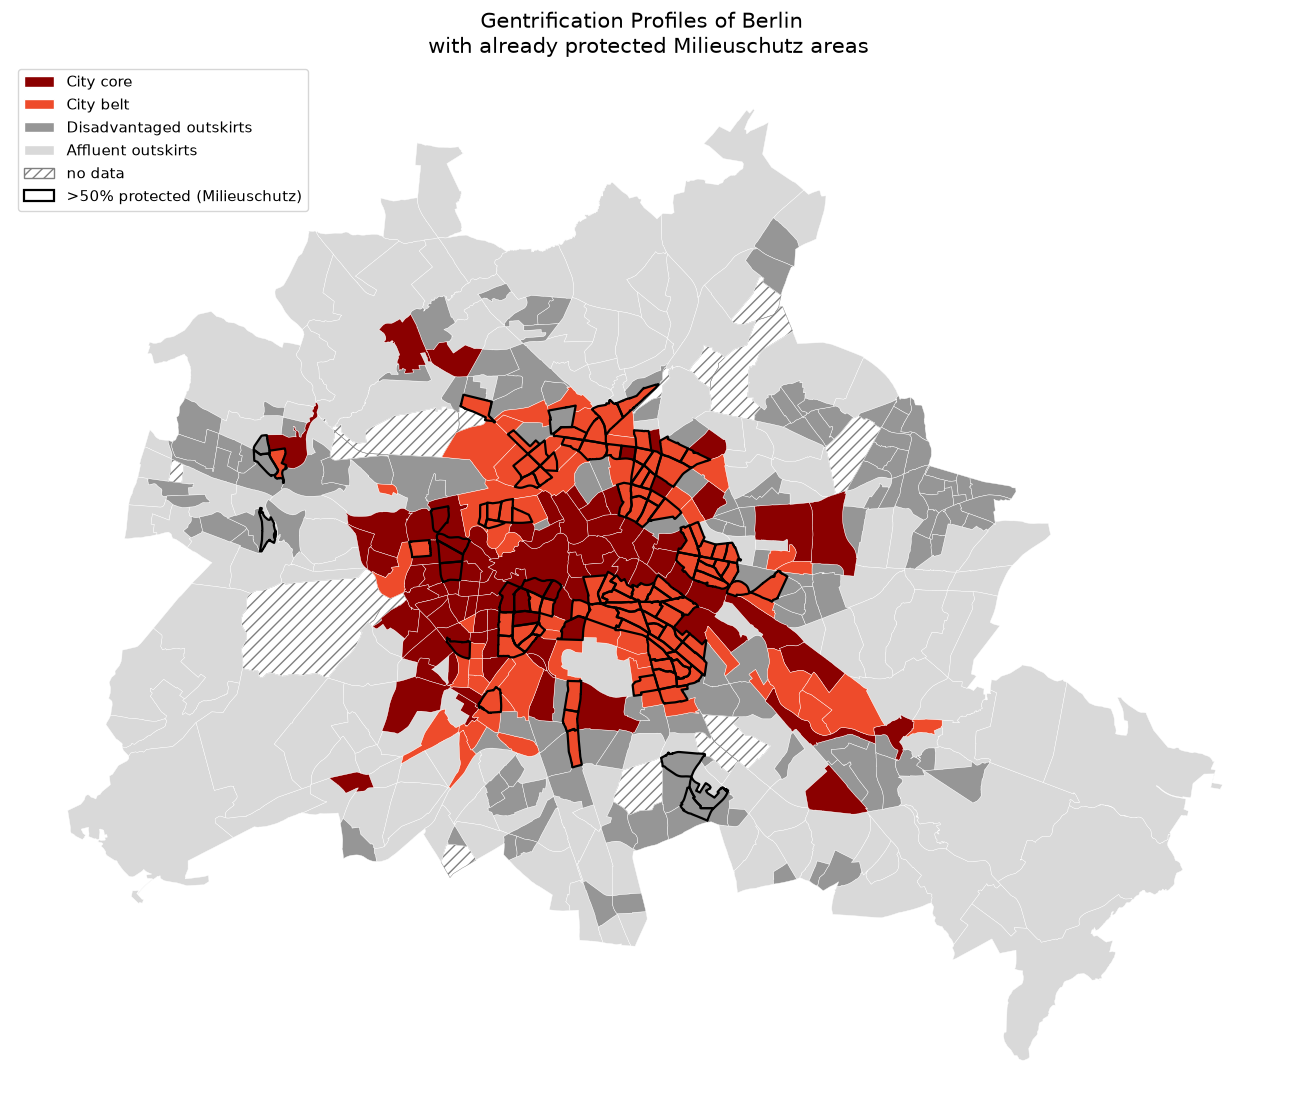

In [21]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)
gdf = plr_geo.merge(
    df[["plr_id_str", "cluster_4k", "ms_over50", "ms_portion"]],
    left_on="plr_id", right_on="plr_id_str", how="left")

fig, ax = plt.subplots(figsize=(13, 13))

cluster_colors = {
    3: "#EE4B2B",   # City belt — bright red 
    1: "#8B0000",   # City core — dark red 
    2: "#969696",   # Disadvantaged outskirts — mittelgrau
    0: "#d9d9d9",   # Affluent outskirts — helleres grau
}
cluster_labels = {1: "City core", 3: "City belt",
                  2: "Disadvantaged outskirts", 0: "Affluent outskirts"}

# Clusterings
gdf[gdf["cluster_4k"].isna()].plot(ax=ax, color="none", edgecolor="grey",
                                    hatch="///", linewidth=0.3)
for c in [0, 2, 1, 3]:
    gdf[gdf["cluster_4k"] == c].plot(ax=ax, color=cluster_colors[c],
                                      edgecolor="white", linewidth=0.3)

# MS-areas
ms = gdf[gdf["ms_over50"] == 1]
ms.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.6)

# Legend
handles = [Patch(facecolor=cluster_colors[c], edgecolor="white", label=cluster_labels[c])
           for c in [1, 3, 2, 0]]
handles.append(Patch(facecolor="none", edgecolor="grey", hatch="///", label="no data"))
handles.append(Patch(facecolor="none", edgecolor="black", linewidth=1.6, label=">50% protected (Milieuschutz)"))
ax.legend(handles=handles, loc="upper left", fontsize=11, frameon=True)

ax.set_title("Gentrification Profiles of Berlin \n with already protected Milieuschutz areas", fontsize=15)
ax.axis("off"); plt.tight_layout();
fig.savefig("../../plots/gentrification_profiles/cluster_milieuschutz_over50_map.png", dpi=300, bbox_inches="tight")
plt.show()

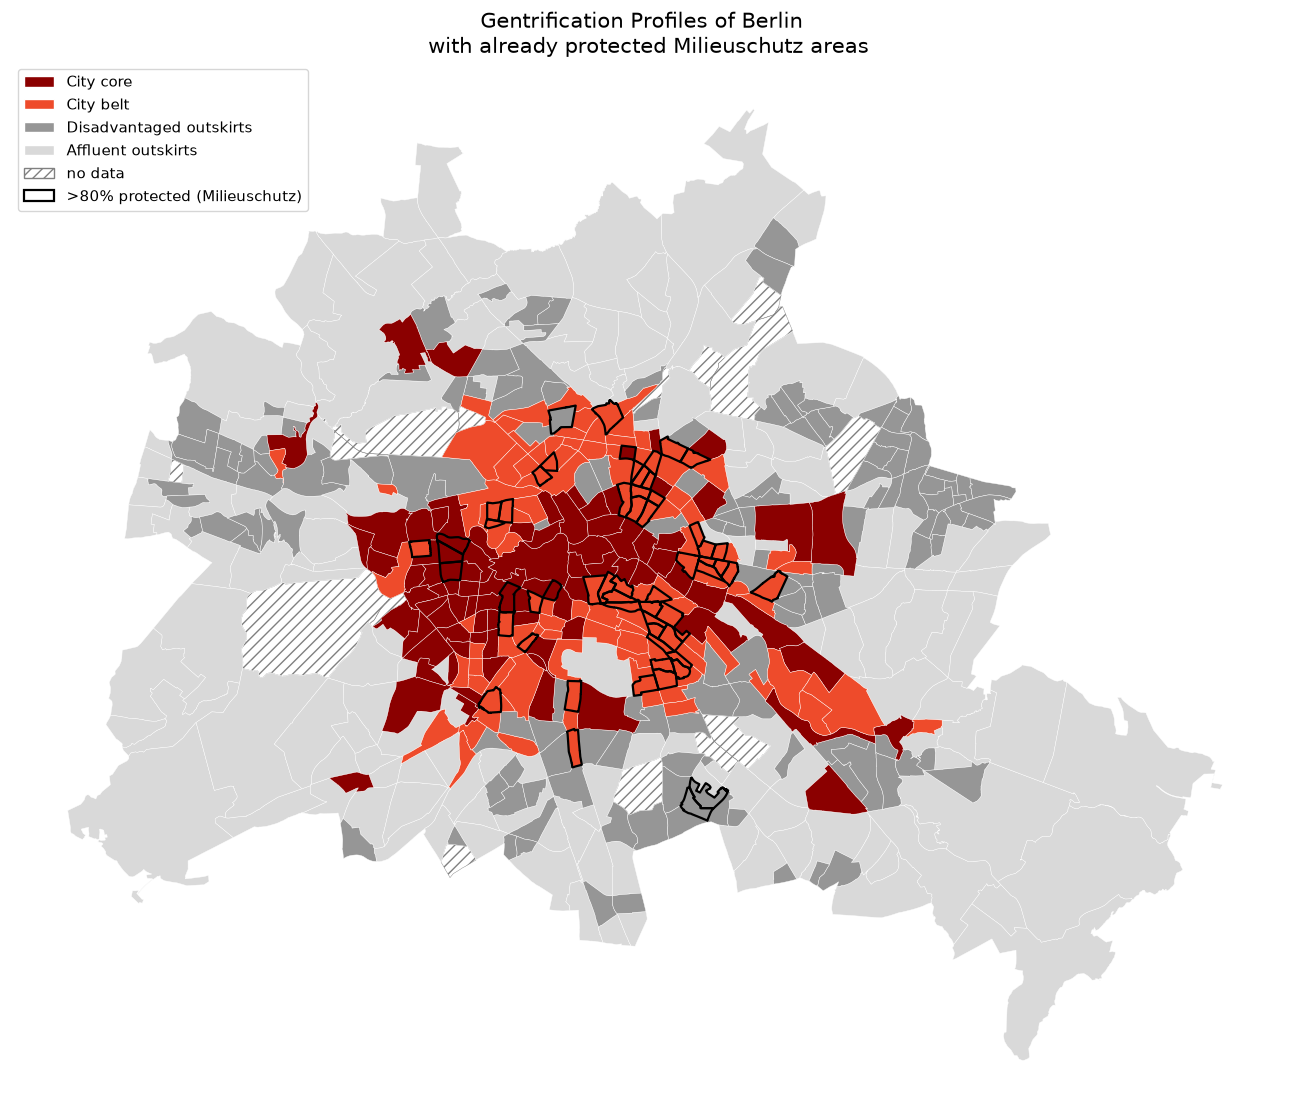

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)
gdf = plr_geo.merge(
    df[["plr_id_str", "cluster_4k", "ms_over80", "ms_portion"]],
    left_on="plr_id", right_on="plr_id_str", how="left")

fig, ax = plt.subplots(figsize=(13, 13))

cluster_colors = {
    3: "#EE4B2B",   # City belt — bright red 
    1: "#8B0000",   # City core — dark red 
    2: "#969696",   # Disadvantaged outskirts — mittelgrau
    0: "#d9d9d9",   # Affluent outskirts — helleres grau
}
cluster_labels = {1: "City core", 3: "City belt",
                  2: "Disadvantaged outskirts", 0: "Affluent outskirts"}

# Clusterings
gdf[gdf["cluster_4k"].isna()].plot(ax=ax, color="none", edgecolor="grey",
                                    hatch="///", linewidth=0.3)
for c in [0, 2, 1, 3]:
    gdf[gdf["cluster_4k"] == c].plot(ax=ax, color=cluster_colors[c],
                                      edgecolor="white", linewidth=0.3)

# MS-areas
ms = gdf[gdf["ms_over80"] == 1]
ms.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.6)

# Legend
handles = [Patch(facecolor=cluster_colors[c], edgecolor="white", label=cluster_labels[c])
           for c in [1, 3, 2, 0]]
handles.append(Patch(facecolor="none", edgecolor="grey", hatch="///", label="no data"))
handles.append(Patch(facecolor="none", edgecolor="black", linewidth=1.6, label=">80% protected (Milieuschutz)"))
ax.legend(handles=handles, loc="upper left", fontsize=11, frameon=True)

ax.set_title("Gentrification Profiles of Berlin \n with already protected Milieuschutz areas", fontsize=15)
ax.axis("off"); plt.tight_layout(); 
fig.savefig("../../plots/gentrification_profiles/cluster_milieuschutz_over80_map.png", dpi=300, bbox_inches="tight")
plt.show()

The Milieuschutz areas cluster clearly on the red City belt and, to a lesser extent, the dark-grey City core — the dense, upgrading inner city where the analysis locates the strongest gentrification pressure. This spatial correspondence between a data-driven typology and an independent policy instrument lends external validity to the clustering: the areas the state has designated as at-risk of displacement largely coincide with those the profile identifies as actively transforming. At the same time, several red City-ring PLRs lie outside any Milieuschutz outline, marking upgrading neighbourhoods not yet covered by the statute — potential protection gaps and, in classification terms, candidate areas for the subsequent analysis.

In [23]:
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)
gdf = plr_geo.merge(
    df[["plr_id_str", "cluster_4k", "ms_over50", "ms_portion"]],
    left_on="plr_id", right_on="plr_id_str", how="left")

# Share of protected areas per Cluster
overlap = (gdf.groupby("cluster_4k")["ms_over50"]
           .agg(["mean", "sum", "count"])
           .rename(columns={"mean": "share_protected",
                            "sum": "n_protected", "count": "n_total"})
           .reindex([1, 3, 2, 0]))          #set order from inner circle to outskirts

overlap.index = overlap.index.map({1:"City core", 3:"City ring",
                                   2:"Disadvantaged outskirts", 0:"Affluent outskirts"})
print(overlap.round(2))

                         share_protected  n_protected  n_total
cluster_4k                                                    
City core                           0.13         12.0       90
City ring                           0.63         90.0      142
Disadvantaged outskirts             0.05          7.0      145
Affluent outskirts                  0.00          0.0      150


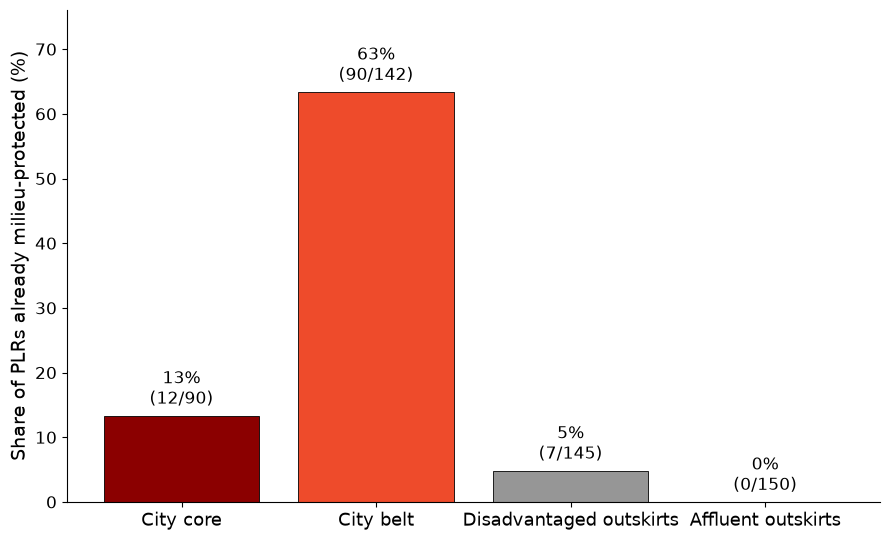

In [40]:
fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(names, shares, color=colors, edgecolor="black", linewidth=0.6)

for bar, s, n, tot in zip(bars, shares, overlap["n_protected"], overlap["n_total"]):
    ax.text(bar.get_x() + bar.get_width()/2, s + 1,
            f"{s:.0f}%\n({int(n)}/{int(tot)})",
            ha="center", va="bottom", fontsize=12)

ax.set_ylabel("Share of PLRs already milieu-protected (%)", fontsize=14)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=12)
ax.set_ylim(0, max(shares) * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig("../../plots/presentation/cluster_milieuschutz50_bar.png", dpi=300, bbox_inches="tight")
plt.show()

Protected areas in Clusters: 
- City core — 13% of PLRs ≥50% protected (12/90). Despite high real-estate values, formal protection is limited; upgrading here is largely complete, so preservation targets it less.
- City belt — 63% of PLRs ≥50% protected (90/142). By far the most protected cluster. Milieuschutz concentrates on exactly the areas the analysis identifies as actively transforming — the strongest evidence that the typology aligns with an independent policy instrument.
- Disadvantaged outskirts — 5% of PLRs ≥50% protected (7/145). Almost no protection, consistent with a socially strained periphery under no upgrading pressure.
- Affluent outskirts — 0% of PLRs ≥50% protected (0/150). No protection at all — a settled, wealthy periphery where displacement is not a policy concern.

The majority of the city ring is already protected. What is going on in the PLRs that are not protected (yet)? Are they different from the ones that are protected?

In [25]:
cl3_unprotected = df.loc[(df['cluster_4k'] == 3) & (df['ms_over50'] == 0)]
cl3_protected = df.loc[(df['cluster_4k'] == 3) & (df['ms_over50'] == 1)]

# Vergleich: geschützte vs. ungeschützte City-ring-PLR
grp = df[df["cluster_4k"] == 3].groupby("ms_over50")[feat_cols].mean().T
grp.columns = ["unprotected", "protected"]
grp["diff (prot - unprot)"] = (grp["protected"] - grp["unprotected"])

# sort by dimension
grp["absdiff"] = grp["diff (prot - unprot)"].abs()
print(f"City ring: {len(cl3_protected)} protected vs {len(cl3_unprotected)} unprotected\n")
print(grp.sort_values("absdiff", ascending=False).drop(columns="absdiff").round(3).to_string())

City ring: 90 protected vs 52 unprotected

                                                              unprotected  protected  diff (prot - unprot)
re_brw_niveau                                                    1889.327   2752.134               862.806
com_n_gastro                                                       33.407     60.652                27.245
re_dichte_all                                                       7.640     14.717                 7.076
re_miete_niveau                                                    16.067     16.640                 0.573
com_median_age_level_2026                                           5.962      5.767                -0.195
re_miete_trend                                                      1.226      1.384                 0.159
re_altbau_share                                                     0.407      0.553                 0.146
re_leerstandsquote                                                  2.099      1.995                -

**Protected vs. unprotected City belt PLRs:** Within the City belt, the 90 majority-protected PLRs differ from the 52 unprotected ones mainly in how far upgrading has advanced. Protected PLRs have markedly higher land values (BRW 2752 vs. 1889), nearly double the gastronomy count (61 vs. 33) and Airbnb density (14.7 vs. 7.6), and a higher pre-war building share (0.55 vs. 0.41). Most other variables barely differ, and rent levels are almost identical (16.6 vs. 16.1). The unprotected PLRs are thus a "lighter" version of the same cluster — earlier in the upgrading process. This suggests Milieuschutz targets the areas under the strongest pressure, and marks the unprotected City belt PLRs as candidate areas for future protection — the unlabeled positives for the subsequent classification stage.

## Final Cluster Profiles 

### Short Profiles 

**City core: The high-value inner city where gentrification is already advanced**
- Highest rents, land values and Airbnb density; steepest rent increase
- Most gastronomy, fewest solo businesses, lowest exit rate; low benefit dependency
- 13% of PLRs majority-protected by Milieuschutz 

**City belt:**
- Highest share of buildings built before 1919, high land value and Airbnb density, strong rent increase
- Youngest residents, smallest households; active churn (elevated exit rate, strong gastronomy)
- 63% of PLRs majority-protected — by far the most protected cluster
- **The actively transforming inner city — gentrification in progress**

**Disadvantaged outskirts:**
- Lowest rents and land values, negligible Airbnb; weakest rent growth
- Highest benefit dependency and single-parent share; most solo businesses, highest exit rate
- 5% of PLRs majority-protected — almost no coverage
- **Socially strained periphery, little upgrading pressure**

**Affluent outskirts:**
- Land values and rents below city average; lowest young-adult share
- Lowest benefit dependency, largest households, oldest businesses, most newer buildings 
- 0% of PLRs protected — displacement not a policy concern
- **Settled, prosperous, family-oriented periphery — not gentrifying**


### Detailed Profiles

#### City Core

- **Location.** The established inner city — concentrated in Mitte and Charlottenburg-Wilmersdorf, extending into the central parts of Friedrichshain-Kreuzberg. 
- **Real estate:** The highest land and rent values in the city (median rent €20.0/m²), the densest Airbnb concentration, and the steepest rent increase of all clusters since 2021 — despite already being high-value, it remains under upward pressure.
- **Social:** Small households and low benefit dependency (median share 7%); an above-average share of younger adults aged 18-45, but less pronounced than the City belt.
- **Commercial:** The most mature commercial fabric: the highest gastronomy count, the highest share of upscale gastronomy, the fewest solo businesses (median 59% solo business share), and the lowest business exit rate — an economy of larger, established firms.
- **Watchlist:** 7 unprotected City core PLRs highly resemble already-protected areas - prime candidates for future protection
- **Summary:** The high-value inner city where gentrification is already advanced; defined by peak real-estate value and commercial consolidation. Distinguished from the City belt by maturity rather than location.

#### City Belt

- **Location:** The inner-city belt around the core — districts Friedrichshain-Kreuzberg, Neukölln-Nord, and parts of Pankow and Mitte. 
- **Real estate:** High rents and Airbnb density with a strong rent increase since 2021, but the defining feature is the highest share of buildings built before 1919 in the city (median share 51%) — the characterful older stock typical of gentrifying areas.
- **Social:** The youngest residents — the largest younger-adult share (median share 50%) in the smallest households.
- **Commercial:** A strong commercial base paired with an elevated business exit rate (median 15% exit rate in the first half of 2026) — the signature of active turnover rather than the core's stability.
- **Milieu protection:** 63% of PLRs majority-protected — by far the most protected cluster. Protection concentrates on exactly the areas the analysis flags as actively transforming, and the protected PLRs are further advanced than the unprotected ones.
- **Watchlist:** 17 unprotected City belt PLRs closely resemble already-protected areas — prime candidates for future protection.
- **Summary:** The actively transforming inner city — gentrification in progress; driven by the pre-1919 building fabric and demographic and commercial churn.

#### Disadvantaged Outskirts

- **Location:** The peripheral housing estates — districts Marzahn-Hellersdorf, Lichtenberg, and Spandau, largely the large post-war estates at the city's edge.
- **Real estate:** The lowest values in the city (median rent €10.3/m²), negligible Airbnb density, and the weakest rent increase since 2021 — almost no upgrading pressure.
- **Social:** The defining dimension — the highest benefit dependency in the city (median share 13%) alongside the highest single-parent share, marking socioeconomic strain.
- **Commercial:** A sparse, unstable commercial base with the highest business exit rate (median 16% exit rate in the first half of 2026) and the youngest businesses.
- **Milieu protection:** 5% of PLRs majority-protected — almost none, consistent with an area under no upgrading pressure.
- **Summary:** A socially strained periphery that gentrification is passing by; driven by socioeconomic strain rather than any upgrading dynamic, and distinguished from the Affluent outskirts purely by its social profile.

#### Affluent Outskirts

- **Location:** The prosperous residential periphery — districts Steglitz-Zehlendorf, outer Pankow, and Reinickendorf, the low-density villa and family-housing areas at the city's edge.
- **Real estate:** Below-average rents (median €14.0/m²), but the most stable price trend of all clusters and the highest share of new buildings. 
- **Social:** The lowest benefit dependency in the city (median share 5%), the largest households, and the lowest young-adult share of all four clusters — an older, family-oriented population.
- **Commercial:** The oldest, most established businesses (median age 8 years) with an above-average upscale share but few venues overall — a small, stable local economy.
- **Milieu protection:** 0% of PLRs protected — displacement is not a policy concern here.
- **Summary:** A settled, prosperous, family-oriented periphery that is not gentrifying; driven by residential affluence and stability, sharing the Disadvantaged outskirts' peripheral location but its social opposite.

### Waffle Plot: Clusters and Watchlist

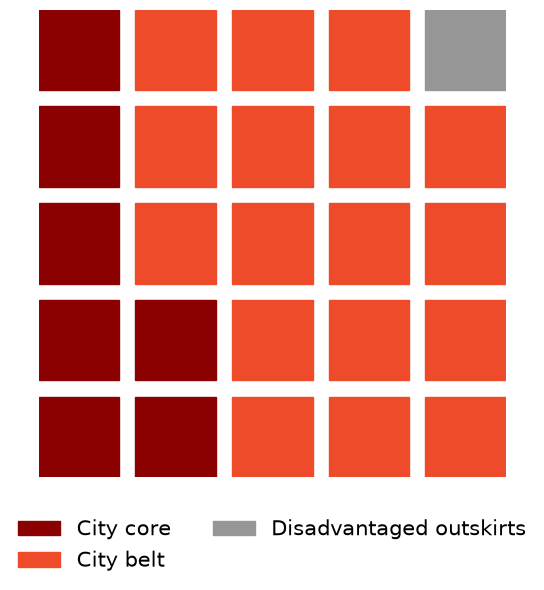

In [57]:
import pandas as pd
from pywaffle import Waffle
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Cluster colors (from the established style guide)
# -----------------------------------------------------------
cluster_colors = {
    "City core": "#8B0000",
    "City belt": "#EE4B2B",
    "Disadvantaged outskirts": "#969696",
    "Affluent outskirts": "#D9D9D9",
}

# -----------------------------------------------------------
# ASSUMPTION: cluster_4k currently holds integer labels (0-3),
# not the cluster names. Adjust this mapping to match your
# actual label encoding before running.
# -----------------------------------------------------------
cluster_names = {1: "City core", 3: "City belt",
                  2: "Disadvantaged outskirts", 0: "Affluent outskirts"}
# -----------------------------------------------------------
# Subset to the watchlist and count by cluster
# -----------------------------------------------------------
watchlist = df_merge2.loc[df_merge2["on_watchlist"]].copy()
watchlist["cluster_name"] = watchlist["cluster_4k"].map(cluster_names)

counts = (
    watchlist["cluster_name"]
    .value_counts()
    .reindex(cluster_colors.keys(), fill_value=0)
)

n_total = int(counts.sum())
assert n_total == 25, f"Expected 25 PLRs on the watchlist, found {n_total}"

# Drop clusters with zero count so pywaffle doesn't render an empty legend entry
counts = counts[counts > 0]

# -----------------------------------------------------------
# Waffle chart
# -----------------------------------------------------------
plt.figure(
    FigureClass=Waffle,
    rows=5,
    values=counts.to_dict(),
    colors=[cluster_colors[c] for c in counts.index],

    legend={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.05),
        "ncol": 2,
        "framealpha": 0,
        "fontsize": 15,
    },
    figsize=(6, 6),
)

plt.tight_layout()
plt.savefig("../../plots/presentation/cluster_watchlist_waffle.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
counts = (
    df.loc[df_merge2["on_watchlist"], "cluster_4k"]
    .value_counts()
    .sort_index()
)
print(counts)
print("Total on watchlist:", counts.sum())

cluster_4k
1     7
2     1
3    17
Name: count, dtype: int64
Total on watchlist: 25


## Add-on 1: Clusters based on change variables only

Earlier, it became clear that the trend variables did not contribute much to the clustering. This is an exploration whether clustering on the trend variables alone adds any value.

In [26]:
id_cols = ["plr_id", "plr_name", "bez"]
non_features = id_cols + ["cluster_3k", "cluster_4k", "ms_portion", "ms_over50", "plr_id_str","ms_over60","ms_over70","ms_over80","ms_over90"]
feat_cols = [c for c in df.columns if c not in non_features]
print(len(feat_cols), "Features") 

X = df[feat_cols]

# keep plr_id retrievable; work on a feature-only matrix
X = df[feat_cols].copy()
ids = df[id_cols].copy()

# 1) impute the 3 gaps (2 PLRs) from similar PLRs
X_imp = pd.DataFrame(
    KNNImputer(n_neighbors=3).fit_transform(X),
    columns=feat_cols, index=df.index,
)


X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X_imp),
    columns=feat_cols, index=X_imp.index,
)

X_scaled.head(3)

42 Features


,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,1.707607,1.345248,1.062483,1.401119,-0.514159,0.938569,0.789265,-0.423212,-0.854709,-1.183481,...,-0.059062,-0.227172,1.531979,0.952109,0.959637,-1.143363,-0.728138,-0.314274,-0.225292,0.638800
1,1.219387,0.033646,1.781115,1.306092,-1.096115,1.599031,0.985896,-0.282827,-1.223596,-0.004727,...,0.407217,0.680906,1.898433,0.860206,1.724478,-0.424651,-1.854356,1.880504,0.381165,1.777773
2,1.767611,0.419433,0.074113,1.329091,-1.175228,1.284139,0.736851,0.555171,-0.191582,-0.444817,...,-0.021163,0.706418,2.197820,-0.451547,-0.201956,-0.461120,-1.439860,0.830252,0.755869,0.929094


In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

change_cols = [c for c in feat_cols if any(t in c for t in ["_trend","_slope","_change"])]
X_change = X_scaled[change_cols]     # schon standardisiert (Option A)
print(f"{len(change_cols)} change-Variablen")

# Elbow + Silhouette über k
Ks = range(2, 9)
wcss, sils = [], []
for k in Ks:
    km = KMeans(k, n_init=10, random_state=0).fit(X_change)
    wcss.append(km.inertia_)
    sils.append(silhouette_score(X_change, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14,5))
a1.plot(Ks, wcss, "o-"); a1.set_title("Elbow — change only"); a1.set_xlabel("k")
a2.plot(Ks, sils, "o-"); a2.set_title("Silhouette — change only"); a2.set_xlabel("k")
plt.show()

for k, s in zip(Ks, sils):
    print(f"k={k}: silhouette = {s:.3f}")

21 change-Variablen


ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

The silhouette scores are alarmingly low and the elbow plot almost looks like a straight line. Thus, even when clustering on the dynamic variables alone, the differences are not enough for a solid clustering base. 